In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, f1_score

### Data Summary

In [2]:
groundtruth_df = pd.read_csv('../../data/groundtruth_df_target_data_split_v2.csv')

In [3]:
groundtruth_df.head(10)

,Unnamed: 0,curve_idx,target,sample_type,sample_id,igi_call,cycle_no,Fn,rn,groundtruth,split,Igi_call_quant,groundtruth_target
0,39,24933,S gene,Negative Control (qPCR),S252611,Negative,40,193254.12,193254.125000,-1,train,0,0
1,79,24165,N gene,Negative Control (qPCR),S252611,Negative,40,125421.22,125421.218750,-1,train,0,0
2,119,24549,ORF1ab,Negative Control (qPCR),S252611,Negative,40,243693.60,243693.593750,-1,train,0,0
3,159,23781,MS2,Negative Control (qPCR),S252611,Negative,40,231175.30,231175.296875,-1,train,0,0
4,199,24934,S gene,Negative Control (qPCR),S305273,Negative,40,190481.00,190481.000000,-1,val,0,0
5,239,24166,N gene,Negative Control (qPCR),S305273,Negative,40,122601.78,122601.781250,-1,val,0,0
6,279,24550,ORF1ab,Negative Control (qPCR),S305273,Negative,40,232959.47,232959.468750,-1,val,0,0
7,319,23782,MS2,Negative Control (qPCR),S305273,Negative,40,224188.44,224188.437500,-1,val,0,0
8,359,24957,S gene,Negative Control (qPCR),S305274,Negative,40,174557.83,174557.828125,-1,train,0,0
9,399,24189,N gene,Negative Control (qPCR),S305274,Negative,40,113986.38,113986.382812,-1,train,0,0


In [5]:
# Assuming groundtruth_df is your dataframe
grouped_counts = groundtruth_df.groupby(['sample_type', 'target', 'groundtruth_target']).size().reset_index(name='counts')

# Display the result
display(grouped_counts)

,sample_type,target,groundtruth_target,counts
0,Clinical Sample,MS2,1,5103
1,Clinical Sample,RnaseP,1,15783
2,Human Normal Negative Control (Extraction),E gene,0,178
3,Human Normal Negative Control (Extraction),MS2,1,64
4,Human Normal Negative Control (Extraction),N gene,0,242
5,Human Normal Negative Control (Extraction),ORF1ab,0,64
6,Human Normal Negative Control (Extraction),RnaseP,1,178
7,Human Normal Negative Control (Extraction),S gene,0,64
8,Negative Control (qPCR),E gene,0,336
9,Negative Control (qPCR),MS2,0,133


## Plots

In [2]:
def calc_metrics(y_true, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=np.array([0,1])).ravel()
    
    return pd.DataFrame({'acc': accuracy_score(y_true, pred),
                         'f1': f1_score(y_true, pred),
                         'tn': tn,
                         'fp': fp,
                         'fn': fn,
                         'tp': tp}, index=np.array([0]))
    
def summary_table(df):
    result_dict = {}
    uniq_df =  df[['curve_idx','groundtruth_label']].drop_duplicates().reset_index()
    result_dict['n_curves'] = uniq_df.curve_idx.nunique()
    result_dict['pos_perc'] = uniq_df.groundtruth_label.sum()/uniq_df.shape[0]
    
    try:
        result_dict['n_sample'] = df.sample_id.nunique()
    except:
        return pd.DataFrame(result_dict, index=[0])
    
    return pd.DataFrame(result_dict, index=[0])
    

In [3]:
old_data_dir = '/media/ssd1/huong/PCR-huong/data'
new_data_dir = os.path.join(old_data_dir, 'new_data')
old_modeloutput_dir = os.path.join(old_data_dir, 'model_outputs')
new_modeloutput_dir = os.path.join(new_data_dir, 'model_outputs')

In [4]:

cycle_range_dict = {'LuNER':{'other': np.arange(35,46),
                            #  'E gene': np.concatenate([np.arange(35,40), np.arange(41,46)]),
                             'RnaseP': np.arange(30,41)},
                    'Thermo': np.arange(30,41)}
                    
fn_range = np.arange(-.9, 0.9, 0.05)

In [5]:
curve_df = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='curve_data')
sample_info = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='igi_gene_call')

join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))

join_df['test_kit'] = join_df.groupby('sample_id').curve_idx.transform(lambda x: x.nunique())
join_df['test_kit'] = np.where(join_df.test_kit == 3, 'LuNER', 'Thermo')

test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_test_pred_df.csv'))
# test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'experimental/seq_test_pred_df.csv'))
groundtruth_df = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))
print(test_pred.shape)
test_pred = (test_pred
             .merge(groundtruth_df.loc[groundtruth_df.split=='test',['curve_idx','sample_id','igi_call','groundtruth']]
                    .drop_duplicates(),
                    on='curve_idx')
             )
print(test_pred.shape)
test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)


(6175, 4)
(6175, 7)


In [6]:
# def convert_df(df):
#     try:
#         df['date'] = pd.to_datetime(df.created_date)
#     except:
#         df['date'] = np.nan
#     return df

# df = groundtruth_df.merge(join_df.loc[(join_df.cycle_no == 1), 
#                                       ['curve_idx','created_date']])
# dt_df = df.groupby(['created_date']).apply(func=convert_df).reset_index(drop=True)
# dt_df.groupby('split').agg(max_date = ('date','max'),
#                            min_date = ('date', 'min'))

In [68]:

retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_retest_pred_df.csv'))
# retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'experimental/seq_retest_pred_df.csv'))
print(retest_pred.shape)
retest_groundtruth = pd.read_csv(os.path.join(old_data_dir, 'retest_df_target_data.csv'))
retest_pred = (retest_pred
               .merge(retest_groundtruth[['curve_idx','target','sample_id','groundtruth_target','igi_call']]
                      .loc[(retest_groundtruth.final_patient_result != 'ReSample') &
                          (~retest_groundtruth.final_patient_result.isna()) &
                      (~retest_groundtruth.curve_idx.isin(groundtruth_df[groundtruth_df.split.isin(['train','val'])].curve_idx))]
                        #   (~retest_groundtruth.target.isin(['RnaseP','MS2']))]
                          )
               .rename(columns={'groundtruth_target':'groundtruth_label'}))
# )
retest_pred['encoded_igi_call'] = 1*(retest_pred.igi_call == 'Positive')
print(retest_pred.shape)

thermo_sample_ids = retest_pred[retest_pred.target == 'ORF1ab'].sample_id.unique()
retest_pred['test_kit'] = 'LuNER'
retest_pred.loc[retest_pred.sample_id.isin(thermo_sample_ids),'test_kit'] = 'Thermo'

df = retest_pred.groupby(['sample_id','test_kit']).curve_idx.nunique().reset_index()
invalid_sample_ids = df[((df.test_kit == 'LuNER') & (df.curve_idx != 3)) | ((df.test_kit == 'Thermo') & (df.curve_idx != 4))].sample_id
retest_pred = retest_pred[~retest_pred.sample_id.isin(invalid_sample_ids)]
print('Number of valid retest samples:', retest_pred.sample_id.nunique())


(4084, 4)
(3028, 9)
Number of valid retest samples: 279


In [8]:

# df = retest_pred.merge(join_df.loc[(join_df.cycle_no == 1), 
#                                       ['curve_idx','created_date']])
# dt_df = df.groupby(['created_date']).apply(func=convert_df).reset_index(drop=True)
# dt_df.agg(max_date = ('date','max'),
#                            min_date = ('date', 'min'))

In [69]:
qpcr_test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_groundtruth_pred.csv'))
qpcr_test_pred = qpcr_test_pred[qpcr_test_pred.split == 'test']

qpcr_retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_retest_pred.csv'))
print(qpcr_retest_pred.shape)
qpcr_retest_pred = (qpcr_retest_pred.merge(retest_pred[['curve_idx']], on='curve_idx'))
print(qpcr_retest_pred.shape)

(4084, 4)
(912, 4)


In [70]:
qpcrdeepnet_pred = pd.read_csv('/media/ssd1/huong/PCR-huong/qpcrdeepnet/output/rn_test_aiprediction_Thu_18Apr2024_22_31_26UTC.tsv', sep='\t')
qpcrdeepnet_pred['encoded_pred'] = 1*(qpcrdeepnet_pred.prediction == 'Positive')
qpcrdeepnet_pred['prob'] = qpcrdeepnet_pred.probability.apply(lambda x: np.float64(x.replace('[','').replace(']','')))

test_qpcrdeepnet = (qpcrdeepnet_pred
                    .merge(groundtruth_df.loc[groundtruth_df.split == 'test', ['curve_idx','groundtruth_target']], left_on='id1', right_on='curve_idx'))

retest_groundtruth = pd.read_csv(os.path.join(old_data_dir, 'retest_df_target_data.csv'))
retest_qpcrdeepnet = (qpcrdeepnet_pred
                      .merge(retest_pred[['curve_idx','groundtruth_label']], left_on='id1', right_on='curve_idx'))
print(retest_qpcrdeepnet.shape)

(912, 10)


In [71]:
humanbased_test = pd.read_csv('/media/ssd1/huong/PCR-huong/data/model_outputs/human_based_fusion_vit_delta64_test_pred_df.csv')
humanbased_retest = pd.read_csv('/media/ssd1/huong/PCR-huong/data/model_outputs/human_based_fusion_vit_delta64_retest_pred_df.csv')
humanbased_retest = (humanbased_retest
                      .merge(retest_pred[['curve_idx']], on='curve_idx'))

In [72]:
(retest_pred
 .merge(join_df.loc[join_df.cycle_no == 1,['curve_idx','test_kit']], on='curve_idx')
 .groupby('test_kit').sample_id.nunique()
 )

KeyError: 'test_kit'

In [13]:
(retest_pred
 .merge(join_df.loc[join_df.cycle_no == 1,['curve_idx','current_sample_result']], on='curve_idx')
 .groupby('current_sample_result').sample_id.nunique()
 )

current_sample_result
Inconclusive    314
Invalid         876
Negative          8
Positive          1
Name: sample_id, dtype: int64

In [14]:
# known_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_known_val_test_pred_df.csv'))
# karlen_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_karlen_val_test_pred_df.csv'))
# chip60_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_chip60_val_test_pred_df.csv'))

# join_df = pd.read_pickle(os.path.join(new_data_dir, 'new_join_df_1.pkl'))
# thermo_sample_ids = join_df[join_df.target == 'MS2'].sample_id.unique()
# join_df['test_kit'] = 'LuNER'
# join_df.loc[join_df.sample_id.isin(thermo_sample_ids),'test_kit'] = 'Thermo'


In [15]:
# test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_groundtruth_pred.csv'))
# groundtruth_df = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))
# print(test_pred.shape)
# test_pred = (test_pred
#              .merge(groundtruth_df.loc[groundtruth_df.split=='test',['curve_idx','sample_id','igi_call','groundtruth']]
#                     .drop_duplicates(),
#                     on='curve_idx')
#              .rename(columns={'prob':'outputs'})
#              )
# print(test_pred.shape)

# test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
# test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)

# retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_retest_pred.csv'))
# print(retest_pred.shape)
# retest_groundtruth = pd.read_csv(os.path.join(old_data_dir, 'retest_df_target_data.csv'))
# retest_pred = (retest_pred
#                .merge(retest_groundtruth.loc[(retest_groundtruth.final_patient_result != 'ReSample') &
#                           (~retest_groundtruth.final_patient_result.isna()),
#                         #   (~retest_groundtruth.target.isin(['RnaseP','MS2'])),
#                           ['curve_idx','groundtruth_target','igi_call']])
#                .rename(columns={#'groundtruth_target':'groundtruth_label',
#                                 'prob':'outputs'}))
# retest_pred['encoded_igi_call'] = 1*(retest_pred.igi_call == 'Positive')
# print(retest_pred.shape)


In [18]:
# test_pred = pd.read_csv(os.path.join(new_modeloutput_dir, '3_20_ImageModel_large_no_invalid_groundtruth_val_test_pred_df.csv'))
# groundtruth_df = pd.read_csv(os.path.join(new_data_dir, 'new_groundtruth_df_no_invalid.csv'))
# print(test_pred[test_pred.split == 'test'].shape)
# test_pred = (test_pred[test_pred.split == 'test']
#              .merge(groundtruth_df.loc[groundtruth_df.cycle_no == 1,['curve_idx','sample_id','igi_call','groundtruth']].drop_duplicates(),
#                     on='curve_idx')
#              )
# print(test_pred.shape)
# test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
# test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)

# retest_pred = pd.read_csv(os.path.join(new_modeloutput_dir, '3_20_ImageModel_large_no_invalid_new_retest_1_val_test_pred_df.csv'))
# print(retest_pred.shape)
# retest_groundtruth = pd.read_csv(os.path.join(new_data_dir, 'new_retest_df_target_data_1.csv'))
# retest_pred = (retest_pred
#                .merge(retest_groundtruth
#                       .loc[(retest_groundtruth.final_patient_result != 'ReSample') &
#                           (~retest_groundtruth.final_patient_result.isna()),
#                         #   (~retest_groundtruth.target.isin(['RnaseP','MS2'])),
#                           ['curve_idx','sample_id','groundtruth_target','igi_call']])
#                .rename(columns={'groundtruth_target':'groundtruth_label'}))
# retest_pred['encoded_igi_call'] = 1*(retest_pred.igi_call == 'Positive')
# print(retest_pred.shape)

In [17]:
summary_table(test_pred)

,n_curves,pos_perc,n_sample
0,6175,0.899109,5517


In [18]:
summary_table(retest_pred)

,n_curves,pos_perc,n_sample
0,2749,0.100764,1199


### vary model threshold

In [73]:
model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    test_pred['pred'] = 1*(test_pred.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(test_pred.groundtruth_label, test_pred.pred, labels=np.array([0,1])).ravel()
    
    model_dict['thres'].append(i)
    model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    model_dict['fnr'].append(fn/(fn+tp))
    model_dict['fpr'].append(fp/(fp+tn))
    model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
model_dict_df = pd.DataFrame(model_dict)
    

In [74]:
best_acc_threshold_idx = model_dict_df.acc.idxmax()
best_acc_threshold = model_dict_df.loc[best_acc_threshold_idx, 'thres']
print('Best Accuracy on Test:', model_dict_df.loc[best_acc_threshold_idx, 'acc'])
print('Best Accuracy Threshold on Test:', best_acc_threshold)

Best Accuracy on Test: 0.9872064777327936
Best Accuracy Threshold on Test: 0.5660000000000001


In [75]:
print('Number of Na predictions in test set:', test_pred.outputs.isna().sum())
model_test_auc = roc_auc_score(test_pred[~test_pred.outputs.isna()].groundtruth_label, test_pred[~test_pred.outputs.isna()].outputs)
print('Model AUC on test set:', model_test_auc)
test_pred['pred'] = 1*(test_pred.outputs >= best_acc_threshold)
calc_metrics(test_pred.groundtruth_label, test_pred.pred)

Number of Na predictions in test set: 0
Model AUC on test set: 0.997836882057165


,acc,f1,tn,fp,fn,tp
0,0.987206,0.992878,589,34,45,5507


In [76]:
igi_test_auc = roc_auc_score(test_pred.groundtruth_label, test_pred.encoded_igi_call)
igi_true_pos_frac = sum(test_pred.encoded_igi_call == 1)/test_pred.shape[0]
print('IGI true positive fraction:', igi_true_pos_frac)
print('IGI AUC on test set:', igi_test_auc)
df = calc_metrics(test_pred.groundtruth_label, test_pred.encoded_igi_call)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

IGI true positive fraction: 0.8584615384615385
IGI AUC on test set: 0.9773955331412103


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.959352,0.976873,623,0,251,5301,0.045209,0.0


In [77]:
igi_pos_frac_thres = model_dict_df.loc[(model_dict_df.pos_frac <= (igi_true_pos_frac + 0.0002)) & (model_dict_df.pos_frac >= (igi_true_pos_frac - 0.0002))].reset_index()

test_pred['pred'] = 1*(test_pred.outputs >= igi_pos_frac_thres.loc[0,'thres'])
df = calc_metrics(test_pred.groundtruth_label, test_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.959028,0.976688,622,1,252,5300,0.045389,0.001605


In [78]:
true_pos_frac = sum(test_pred.groundtruth_label == 1)/test_pred.shape[0]
print('Test true positive fraction:', true_pos_frac)

Test true positive fraction: 0.8991093117408907


In [79]:
retest_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    retest_pred['pred'] = 1*(retest_pred.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(retest_pred.groundtruth_label, retest_pred.pred, labels=np.array([0,1])).ravel()
    
    retest_model_dict['thres'].append(i)
    retest_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    retest_model_dict['fnr'].append(fn/(fn+tp))
    retest_model_dict['fpr'].append(fp/(fp+tn))
    retest_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
retest_model_dict_df = pd.DataFrame(retest_model_dict)
    

In [80]:
print('Number of Na predictions on retest:', retest_pred.outputs.isna().sum())
model_retest_auc = roc_auc_score(retest_pred[~retest_pred.outputs.isna()].groundtruth_label, 
                                 retest_pred[~retest_pred.outputs.isna()].outputs)
print('Model AUC on retest:', model_retest_auc)
retest_pred['pred'] = 1*(retest_pred.outputs >= best_acc_threshold)
df = calc_metrics(retest_pred.groundtruth_label, retest_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

Number of Na predictions on retest: 0
Model AUC on retest: 0.9357093635148679


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.916667,0.880878,555,29,47,281,0.143293,0.049658


In [81]:
igi_retest_auc = roc_auc_score(retest_pred.groundtruth_label, retest_pred.encoded_igi_call)
retest_igi_true_pos_frac = sum(retest_pred.encoded_igi_call == 1)/retest_pred.shape[0]
print('IGI true positive fraction:', retest_igi_true_pos_frac)
print('IGI AUC on retest:', igi_retest_auc)
df = calc_metrics(retest_pred.groundtruth_label, retest_pred.encoded_igi_call)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

IGI true positive fraction: 0.33223684210526316
IGI AUC on retest: 0.7357375542933512


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.764254,0.659271,489,95,120,208,0.365854,0.162671


In [83]:
retest_model_dict_df.loc[(retest_model_dict_df.pos_frac <= (retest_igi_true_pos_frac + 0.00002)) & (retest_model_dict_df.pos_frac >= (retest_igi_true_pos_frac - 0.00002))]

,thres,acc,fnr,fpr,pos_frac
637,0.637,0.917763,0.152439,0.042808,0.332237
638,0.638,0.917763,0.152439,0.042808,0.332237
639,0.639,0.917763,0.152439,0.042808,0.332237
640,0.640,0.917763,0.152439,0.042808,0.332237
641,0.641,0.917763,0.152439,0.042808,0.332237
642,0.642,0.917763,0.152439,0.042808,0.332237
643,0.643,0.917763,0.152439,0.042808,0.332237
644,0.644,0.917763,0.152439,0.042808,0.332237
645,0.645,0.917763,0.152439,0.042808,0.332237
646,0.646,0.917763,0.152439,0.042808,0.332237


In [84]:
retest_igi_pos_frac_thres = 0.637
# retest_igi_pos_frac_thres = 0.062 #0.026 # fusion
# retest_igi_pos_frac_thres = 0.765 # seq
# retest_igi_pos_frac_thres = 0.863 # img
# retest_igi_pos_frac_thres = .reset_index()

retest_pred['pred'] = 1*(retest_pred.outputs >= retest_igi_pos_frac_thres)
df = calc_metrics(retest_pred.groundtruth_label, retest_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print('Model')
df



Model


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.917763,0.881141,559,25,50,278,0.152439,0.042808


### vary qpcr threshold

In [85]:
qpcr_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    qpcr_test_pred['pred'] = 1*(qpcr_test_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(qpcr_test_pred.groundtruth_label, qpcr_test_pred.pred, labels=np.array([0,1])).ravel()
    
    qpcr_model_dict['thres'].append(i)
    qpcr_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    qpcr_model_dict['fnr'].append(fn/(fn+tp))
    qpcr_model_dict['fpr'].append(fp/(fp+tn))
    qpcr_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
qpcr_model_dict_df = pd.DataFrame(qpcr_model_dict)
    

In [86]:
qpcr_best_acc_threshold_idx = qpcr_model_dict_df.acc.idxmax()
qpcr_best_acc_threshold = qpcr_model_dict_df.loc[qpcr_best_acc_threshold_idx, 'thres']
print('qpcR Best Accuracy on Test:', qpcr_model_dict_df.loc[qpcr_best_acc_threshold_idx, 'acc'])
print('qpcR Best Accuracy Threshold on Test:', qpcr_best_acc_threshold)

qpcR Best Accuracy on Test: 0.9538461538461539
qpcR Best Accuracy Threshold on Test: 0.522


In [87]:
qpcr_model_dict_df.loc[(qpcr_model_dict_df.pos_frac <= (igi_true_pos_frac + 0.0002)) & (qpcr_model_dict_df.pos_frac >= (igi_true_pos_frac - 0.0002))].reset_index()

,index,thres,acc,fnr,fpr,pos_frac
0,631,0.631,0.950769,0.049892,0.043339,0.858623
1,632,0.632,0.950769,0.049892,0.043339,0.858623
2,633,0.633,0.950607,0.050072,0.043339,0.858462


In [88]:
qpcr_test_auc = roc_auc_score(qpcr_test_pred[~qpcr_test_pred.prob.isna()].groundtruth_label, qpcr_test_pred[~qpcr_test_pred.prob.isna()].prob)
print('qPCR AUC on test set:', qpcr_test_auc)

igi_pos_frac_qpcr_thres = 0.632

qpcr_test_pred['pred'] = 1*(qpcr_test_pred.prob >= igi_pos_frac_qpcr_thres)
df = calc_metrics(qpcr_test_pred.groundtruth_label, qpcr_test_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

qPCR AUC on test set: 0.981763867477239


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.950769,0.971992,596,27,277,5275,0.049892,0.043339


In [89]:
qpcr_model_retest_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    qpcr_retest_pred['pred'] = 1*(qpcr_retest_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.pred, labels=np.array([0,1])).ravel()
    
    qpcr_model_retest_dict['thres'].append(i)
    qpcr_model_retest_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    qpcr_model_retest_dict['fnr'].append(fn/(fn+tp))
    qpcr_model_retest_dict['fpr'].append(fp/(fp+tn))
    qpcr_model_retest_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
qpcr_model_retest_dict_df = pd.DataFrame(qpcr_model_retest_dict)
    

In [90]:
qpcr_model_retest_dict_df.loc[(qpcr_model_retest_dict_df.pos_frac <= (retest_igi_true_pos_frac + 0.0002)) & (qpcr_model_retest_dict_df.pos_frac >= (retest_igi_true_pos_frac - 0.0002))]

,thres,acc,fnr,fpr,pos_frac
678,0.678,0.76864,0.359756,0.159247,0.332237


In [91]:
qpcr_test_auc = roc_auc_score(qpcr_retest_pred[~qpcr_retest_pred.prob.isna()].groundtruth_label, qpcr_retest_pred[~qpcr_retest_pred.prob.isna()].prob)
print('qpcR AUC on retest set:', qpcr_test_auc)

retest_igi_pos_frac_qpcr_thres = 0.678
# retest_igi_pos_frac_qpcr_thres = 0.615
qpcr_retest_pred['pred'] = 1*(qpcr_retest_pred.prob >= retest_igi_pos_frac_qpcr_thres)
df = calc_metrics(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print('qpcR')
df

qpcR AUC on retest set: 0.8156235599681623
qpcR


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.76864,0.66561,491,93,118,210,0.359756,0.159247


### vary qPCRdeepNet threshold

In [92]:
deepnet_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    test_qpcrdeepnet['pred'] = 1*(test_qpcrdeepnet.prob >= i)
    tn, fp, fn, tp = confusion_matrix(test_qpcrdeepnet.groundtruth_target, test_qpcrdeepnet.pred, labels=np.array([0,1])).ravel()
    
    deepnet_model_dict['thres'].append(i)
    deepnet_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    deepnet_model_dict['fnr'].append(fn/(fn+tp))
    deepnet_model_dict['fpr'].append(fp/(fp+tn))
    deepnet_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
deepnet_model_dict_df = pd.DataFrame(deepnet_model_dict)
    

In [93]:
deepnet_best_acc_threshold_idx = deepnet_model_dict_df.acc.idxmax()
deepnet_best_acc_threshold = deepnet_model_dict_df.loc[deepnet_best_acc_threshold_idx, 'thres']
print('deepnet Best Accuracy on Test:', deepnet_model_dict_df.loc[deepnet_best_acc_threshold_idx, 'acc'])
print('deepnet Best Accuracy Threshold on Test:', deepnet_best_acc_threshold)

deepnet Best Accuracy on Test: 0.9575708502024292
deepnet Best Accuracy Threshold on Test: 0.87


In [94]:
deepnet_model_dict_df.loc[(deepnet_model_dict_df.pos_frac <= (igi_true_pos_frac + 0.002)) & (deepnet_model_dict_df.pos_frac >= (igi_true_pos_frac - 0.002))].reset_index()

,index,thres,acc,fnr,fpr,pos_frac
0,994,0.994,0.953846,0.047370,0.035313,0.860081
1,995,0.995,0.953198,0.048451,0.032103,0.858785
2,996,0.996,0.952389,0.049352,0.032103,0.857976


In [95]:
qpcrdeepnet_test_auc = roc_auc_score(test_qpcrdeepnet[~test_qpcrdeepnet.prob.isna()].groundtruth_target, test_qpcrdeepnet[~test_qpcrdeepnet.prob.isna()].prob)
print('qPCRdeepNet AUC on test set:', qpcrdeepnet_test_auc)

igi_pos_frac_deepnet_thres = 0.995

test_qpcrdeepnet['pred'] = 1*(test_qpcrdeepnet.prob >= igi_pos_frac_deepnet_thres)
df = calc_metrics(test_qpcrdeepnet.groundtruth_target, test_qpcrdeepnet.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

qPCRdeepNet AUC on test set: 0.9792673731734056


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.953198,0.973376,603,20,269,5283,0.048451,0.032103


In [96]:
deepnet_model_retest_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    retest_qpcrdeepnet['pred'] = 1*(retest_qpcrdeepnet.prob >= i)
    tn, fp, fn, tp = confusion_matrix(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.pred, labels=np.array([0,1])).ravel()
    
    deepnet_model_retest_dict['thres'].append(i)
    deepnet_model_retest_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    deepnet_model_retest_dict['fnr'].append(fn/(fn+tp))
    deepnet_model_retest_dict['fpr'].append(fp/(fp+tn))
    deepnet_model_retest_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
deepnet_model_retest_dict_df = pd.DataFrame(deepnet_model_retest_dict)
    

In [97]:
retest_igi_true_pos_frac

0.33223684210526316

In [99]:
deepnet_model_retest_dict_df.loc[(deepnet_model_retest_dict_df.pos_frac <= (retest_igi_true_pos_frac + 0.0005)) & (deepnet_model_retest_dict_df.pos_frac >= (retest_igi_true_pos_frac - 0.0005))]

,thres,acc,fnr,fpr,pos_frac
998,0.998,0.770833,0.356707,0.157534,0.332237


In [100]:
qpcrdeepnet_retest_auc = roc_auc_score(retest_qpcrdeepnet[~retest_qpcrdeepnet.prob.isna()].groundtruth_label, retest_qpcrdeepnet[~retest_qpcrdeepnet.prob.isna()].prob)
print('qPCRdeepNet AUC on retest set:', qpcrdeepnet_retest_auc)

retest_igi_pos_frac_deepnet_thres = 0.998
retest_qpcrdeepnet['pred'] = 1*(retest_qpcrdeepnet.prob >= retest_igi_pos_frac_deepnet_thres)
df = calc_metrics(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print('qpcR')
df

qPCRdeepNet AUC on retest set: 0.7747765619779485
qpcR


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.770833,0.66878,492,92,117,211,0.356707,0.157534


### vary human based threshold

In [101]:
humanbased_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    humanbased_test['pred'] = 1*(humanbased_test.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(humanbased_test.groundtruth_label, humanbased_test.pred, labels=np.array([0,1])).ravel()
    
    humanbased_model_dict['thres'].append(i)
    humanbased_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    humanbased_model_dict['fnr'].append(fn/(fn+tp))
    humanbased_model_dict['fpr'].append(fp/(fp+tn))
    humanbased_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
humanbased_model_dict_df = pd.DataFrame(humanbased_model_dict)
    

In [102]:
humanbased_best_acc_threshold_idx = humanbased_model_dict_df.acc.idxmax()
humanbased_best_acc_threshold = humanbased_model_dict_df.loc[humanbased_best_acc_threshold_idx, 'thres']
print('humanbased Best Accuracy on Test:', humanbased_model_dict_df.loc[humanbased_best_acc_threshold_idx, 'acc'])
print('humanbased Best Accuracy Threshold on Test:', humanbased_best_acc_threshold)

humanbased Best Accuracy on Test: 0.9057489878542511
humanbased Best Accuracy Threshold on Test: 0.001


In [103]:
igi_true_pos_frac

0.8584615384615385

In [104]:
print(igi_true_pos_frac)
humanbased_model_dict_df.loc[(humanbased_model_dict_df.pos_frac <= (igi_true_pos_frac + 0.06)) & (humanbased_model_dict_df.pos_frac >= (igi_true_pos_frac - 0.06))].reset_index()

0.8584615384615385


,index,thres,acc,fnr,fpr,pos_frac
0,1,0.001,0.905749,0.104647,0.001605,0.805182


In [105]:
humanbased_test_auc = roc_auc_score(humanbased_test[~humanbased_test.outputs.isna()].groundtruth_label, humanbased_test[~humanbased_test.outputs.isna()].outputs)
print('Humanbased AUC on test set:', humanbased_test_auc)

igi_pos_frac_humanbased_thres = 0.001

humanbased_test['pred'] = 1*(humanbased_test.outputs >= igi_pos_frac_humanbased_thres)
df = calc_metrics(humanbased_test.groundtruth_label, humanbased_test.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

Humanbased AUC on test set: 0.9579796559364607


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.905749,0.944698,622,1,581,4971,0.104647,0.001605


In [106]:
humanbased_model_retest_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    humanbased_retest['pred'] = 1*(humanbased_retest.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(humanbased_retest.groundtruth_label, humanbased_retest.pred, labels=np.array([0,1])).ravel()
    
    humanbased_model_retest_dict['thres'].append(i)
    humanbased_model_retest_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    humanbased_model_retest_dict['fnr'].append(fn/(fn+tp))
    humanbased_model_retest_dict['fpr'].append(fp/(fp+tn))
    humanbased_model_retest_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
humanbased_model_retest_dict_df = pd.DataFrame(humanbased_model_retest_dict)
    

In [110]:
print(retest_igi_true_pos_frac)
humanbased_model_retest_dict_df.loc[(humanbased_model_retest_dict_df.pos_frac <= (retest_igi_true_pos_frac + 0.09)) & (humanbased_model_retest_dict_df.pos_frac >= (retest_igi_true_pos_frac - 0.09))]

0.33223684210526316


,thres,acc,fnr,fpr,pos_frac
1,0.001,0.79057,0.442073,0.078767,0.251096


In [111]:
humanbased_retest_auc = roc_auc_score(humanbased_retest[~humanbased_retest.outputs.isna()].groundtruth_label, humanbased_retest[~humanbased_retest.outputs.isna()].outputs)
print('Humanbased AUC on retest set:', humanbased_retest_auc)


retest_igi_pos_frac_humanbased_thres = 0.001
humanbased_retest['pred'] = 1*(humanbased_retest.outputs >= retest_igi_pos_frac_humanbased_thres)
df = calc_metrics(humanbased_retest.groundtruth_label, humanbased_retest.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print('qpcR')
df

Humanbased AUC on retest set: 0.7033860257266955
qpcR


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.79057,0.657092,538,46,145,183,0.442073,0.078767


### vary IGI thresholds
#### test set

##### Move individual pcr plate

In [112]:
full_test_pred = (test_pred
                  .merge(join_df[['curve_idx','target','threshold','pcr_plate','test_kit','thres_ct','cycle_no','drn']].drop_duplicates(),
                         on = 'curve_idx'))
full_test_pred['encoded_igi_call'] = 1*(full_test_pred.igi_call == 'Positive')
print(full_test_pred.shape)

(270020, 17)


In [113]:
thres_ct_df = full_test_pred.loc[full_test_pred.thres_ct != 'Undetermined', ['curve_idx','thres_ct']].drop_duplicates()
thres_ct_df['cycle_no'] = thres_ct_df.thres_ct.apply(lambda x: np.around(float(x)))

new_thres_df = (full_test_pred[['pcr_plate','target','curve_idx','cycle_no','drn']]
                  .merge(thres_ct_df, on=['curve_idx','cycle_no']))
new_thres_df['igi_threshold'] = new_thres_df.groupby(['pcr_plate','target']).drn.transform('mean')

full_test_pred = (full_test_pred
                  .merge(new_thres_df[['curve_idx','igi_threshold']], on =['curve_idx'], how='left')
                  )
full_test_pred.loc[full_test_pred.igi_threshold.isna(),'igi_threshold'] = full_test_pred.loc[full_test_pred.igi_threshold.isna(),'threshold']
print(full_test_pred.shape)
full_test_pred.head(5)

(270020, 18)


,curve_idx,outputs,igi_fp,igi_fn,sample_id,igi_call,groundtruth,encoded_igi_call,groundtruth_label,pred,target,threshold,pcr_plate,test_kit,thres_ct,cycle_no,drn,igi_threshold
0,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,1,178.980698,10249.504305
1,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,2,139.666701,10249.504305
2,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,3,107.274579,10249.504305
3,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,4,80.349253,10249.504305
4,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,5,117.570412,10249.504305


#### systematically shift the Fn threshold and Ct

In [114]:
thres_df = {'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in fn_range:
    for cycle in range(10):
        df = full_test_pred.copy()
        df['new_threshold'] = full_test_pred.igi_threshold * (1 + perc)
        
        df['if_pass'] = df.drn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')
        
        
        # if df.test_kit.iloc[0] == 'Thermo':
        df.loc[df.test_kit == 'Thermo','new_igi_call'] = 1*(df[df.test_kit == 'Thermo'].new_ct <= cycle_range_dict['Thermo'][cycle])
    
        df.loc[(df.test_kit == 'LuNER') & (df.target == 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target == 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle])
        df.loc[(df.test_kit == 'LuNER') & (df.target != 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target != 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['other'][cycle])
        
        df_1 = df[df.cycle_no == 1]
        tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
        
        thres_df['fpr'].append(fp/(fp+tn))
        thres_df['fnr'].append(fn/(fn+tp))
        thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        
        

In [115]:
final_thres_df = pd.DataFrame(thres_df)
final_thres_df['fpr_type'] = 'simulated'
final_thres_df['fnr_type'] = 'simulated'


In [116]:
igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(test_pred.groundtruth_label, test_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
igi_fnr = igi_fn/(igi_fn+igi_tp) 
igi_pos_frac = (igi_fp + igi_tp)/(igi_fp+igi_tp+igi_fn+igi_tn)
igi_fpr = igi_fp/(igi_fp + igi_tn)
print('Current IGI FNR:', igi_fnr)
print('Current IGI FPR:', igi_fpr)
print('Current IGI positive fraction:', igi_pos_frac)

Current IGI FNR: 0.04520893371757925
Current IGI FPR: 0.0
Current IGI positive fraction: 0.8584615384615385


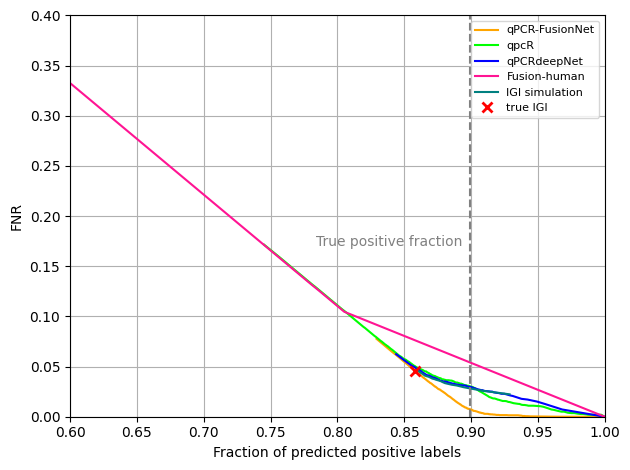

In [117]:
color_map = {'igi': '#008080',
             'fusion': '#ffa500',
             'qpcr':'#00ff00',
             'deepnet': '#0000ff',
             'humanbased': '#ff1493'
             }

plt.plot(model_dict_df.pos_frac, model_dict_df.fnr, color=color_map.get('fusion'), label='qPCR-FusionNet')

plt.plot(qpcr_model_dict_df.pos_frac, qpcr_model_dict_df.fnr, color=color_map.get('qpcr'), label='qpcR')

plt.plot(deepnet_model_dict_df.pos_frac, deepnet_model_dict_df.fnr, color=color_map.get('deepnet'), label='qPCRdeepNet')

plt.plot(humanbased_model_dict_df.pos_frac, humanbased_model_dict_df.fnr, color=color_map.get('humanbased'), label='Fusion-human')

plt.plot(final_thres_df.pos_pred, 
         final_thres_df.fnr, color=color_map.get('igi'), label='IGI simulation')

plt.plot(igi_pos_frac, igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')
plt.axvline(true_pos_frac, linestyle='--', color='gray')
plt.text(x=true_pos_frac - 0.115, y = 0.17, s='True positive fraction', c='gray')
plt.xlim(0.6, 1.0)
plt.ylim(0.0,0.4)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
# plt.title('FNR of different methods when varying thresholds on test set')
plt.tight_layout()
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/fnr_igi_test.png')

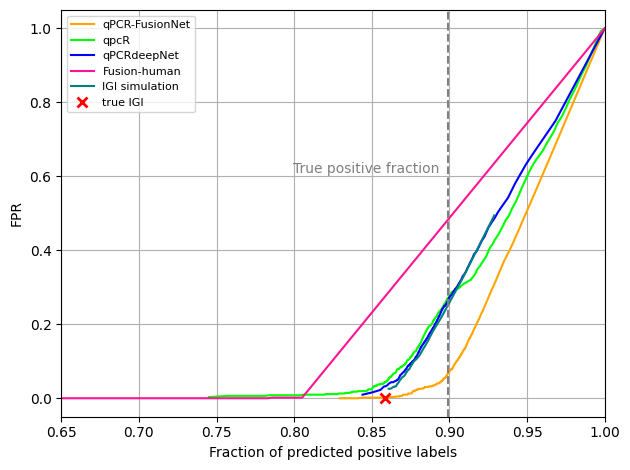

In [118]:
plt.plot(model_dict_df.pos_frac, model_dict_df.fpr, color=color_map.get('fusion'), label='qPCR-FusionNet')

plt.plot(qpcr_model_dict_df.pos_frac, qpcr_model_dict_df.fpr, color=color_map.get('qpcr'), label='qpcR')

plt.plot(deepnet_model_dict_df.pos_frac, deepnet_model_dict_df.fpr, color=color_map.get('deepnet'), label='qPCRdeepNet')

plt.plot(humanbased_model_dict_df.pos_frac, humanbased_model_dict_df.fpr, color=color_map.get('humanbased'), label='Fusion-human')

plt.plot(final_thres_df.pos_pred, 
         final_thres_df.fpr, color=color_map.get('igi'), label='IGI simulation')
plt.plot(igi_pos_frac, igi_fpr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

plt.axvline(true_pos_frac, linestyle='--', color='gray')
plt.text(x=true_pos_frac - 0.1, y = 0.61, s='True positive fraction', c='gray')
plt.xlim(0.65, 1.0)
# plt.ylim(-0.025,0.15)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FPR')
plt.legend(loc='upper left',fontsize=8)
plt.grid()
plt.tight_layout()
# plt.title('FPR of different methods when varying thresholds on test set')
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/fpr_igi_test.png')

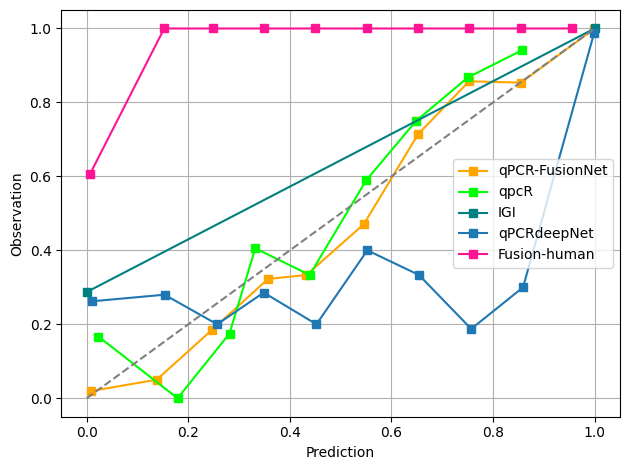

In [119]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(test_pred.groundtruth, test_pred.outputs, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('fusion'), label='qPCR-FusionNet')

prob_true, prob_pred = calibration_curve(qpcr_test_pred.groundtruth_label, qpcr_test_pred.prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('qpcr'), label='qpcR')

prob_true, prob_pred = calibration_curve(test_pred.groundtruth, test_pred.encoded_igi_call, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('igi'), label='IGI')

prob_true, prob_pred = calibration_curve(test_qpcrdeepnet.groundtruth_target, test_qpcrdeepnet.prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('qpcrdeepnet'), label='qPCRdeepNet')

prob_true, prob_pred = calibration_curve(humanbased_test.groundtruth_label, humanbased_test.outputs, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('humanbased'), label='Fusion-human')

plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.grid()
plt.xlabel('Prediction')
plt.ylabel('Observation')
plt.legend()
plt.tight_layout()
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/calibration_test.png')

In [120]:
# final_thres_df.to_csv('/media/ssd1/huong/PCR-huong/data/paper_plots/paper_plots_test_final_thres_df.csv', index=False)

#### retest

In [121]:
full_retest_pred = (retest_pred
                  .merge(join_df[['curve_idx','threshold','pcr_plate','thres_ct','cycle_no','drn']], #'test_kit',
                         on = 'curve_idx'))
# full_retest_pred['encoded_igi_call'] = 1*(full_retest_pred.igi_call == 'Positive')
print(full_retest_pred.shape)

(39540, 16)


In [122]:
true_retest_pos_frac = sum(retest_pred.groundtruth_label==1)/retest_pred.shape[0]
print('True retest positive fraction:', true_retest_pos_frac)


True retest positive fraction: 0.35964912280701755


In [123]:
retest_thres_ct_df = full_retest_pred.loc[full_retest_pred.thres_ct != 'Undetermined', ['curve_idx','thres_ct']].drop_duplicates()
retest_thres_ct_df['cycle_no'] = retest_thres_ct_df.thres_ct.apply(lambda x: np.around(float(x)))

retest_new_thres_df = (full_retest_pred[['pcr_plate','target','curve_idx','cycle_no','drn']]
                  .merge(retest_thres_ct_df, on=['curve_idx','cycle_no']))
retest_new_thres_df['igi_threshold'] = retest_new_thres_df.groupby(['pcr_plate','target']).drn.transform('mean')

full_retest_pred = (full_retest_pred
                  .merge(retest_new_thres_df[['curve_idx','igi_threshold']], on =['curve_idx'], how='left')
                  )


full_retest_pred.loc[full_retest_pred.igi_threshold.isna(),'igi_threshold'] = full_retest_pred.loc[full_retest_pred.igi_threshold.isna(),'threshold']
print(full_retest_pred.shape)
full_retest_pred.head(5)

(39540, 17)


,curve_idx,outputs,igi_fp,igi_fn,target,sample_id,groundtruth_label,igi_call,encoded_igi_call,test_kit,pred,threshold,pcr_plate,thres_ct,cycle_no,drn,igi_threshold
0,108884,0.000376,7.229704e-09,0.000303,E gene,S1160529,0.0,Negative,0,LuNER,0,6000.0,AC00H0VO,Undetermined,1,-1869.934593,6000.0
1,108884,0.000376,7.229704e-09,0.000303,E gene,S1160529,0.0,Negative,0,LuNER,0,6000.0,AC00H0VO,Undetermined,2,-1922.696429,6000.0
2,108884,0.000376,7.229704e-09,0.000303,E gene,S1160529,0.0,Negative,0,LuNER,0,6000.0,AC00H0VO,Undetermined,3,-1456.583264,6000.0
3,108884,0.000376,7.229704e-09,0.000303,E gene,S1160529,0.0,Negative,0,LuNER,0,6000.0,AC00H0VO,Undetermined,4,-844.782600,6000.0
4,108884,0.000376,7.229704e-09,0.000303,E gene,S1160529,0.0,Negative,0,LuNER,0,6000.0,AC00H0VO,Undetermined,5,-579.200685,6000.0


In [124]:
retest_plate_target_pair = full_retest_pred[['pcr_plate','target','test_kit']].drop_duplicates()


### systematically move Fn thresholds

In [125]:
retest_thres_df = {'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in fn_range:
    for cycle in range(10):
        df = full_retest_pred.copy()
        df['new_threshold'] = df.igi_threshold * (1 + perc)
        
        df['if_pass'] = df.drn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')
        
        
        # if df.test_kit.iloc[0] == 'Thermo':
        df.loc[df.test_kit == 'Thermo','new_igi_call'] = 1*(df[df.test_kit == 'Thermo'].new_ct <= cycle_range_dict['Thermo'][cycle])
    
        df.loc[(df.test_kit == 'LuNER') & (df.target == 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target == 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle])
        df.loc[(df.test_kit == 'LuNER') & (df.target != 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target != 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['other'][cycle])
        
        df_1 = df[df.cycle_no == 1]
        tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
        
        retest_thres_df['fpr'].append(fp/(fp+tn))
        retest_thres_df['fnr'].append(fn/(fn+tp))
        retest_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        
        

In [126]:
retest_final_thres_df = pd.DataFrame(retest_thres_df)
retest_final_thres_df['fpr_type'] = 'simulated'
retest_final_thres_df['fnr_type'] = 'simulated'


In [127]:
igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(retest_pred.groundtruth_label, retest_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
retest_igi_fnr = igi_fn/(igi_fn+igi_tp) 
retest_igi_pos_frac = (igi_fp + igi_tp)/(igi_fp+igi_tp+igi_fn+igi_tn)
retest_igi_fpr = igi_fp/(igi_fp + igi_tn)

In [128]:
true_retest_pos_frac = sum(retest_pred.groundtruth_label == 1)/retest_pred.shape[0]

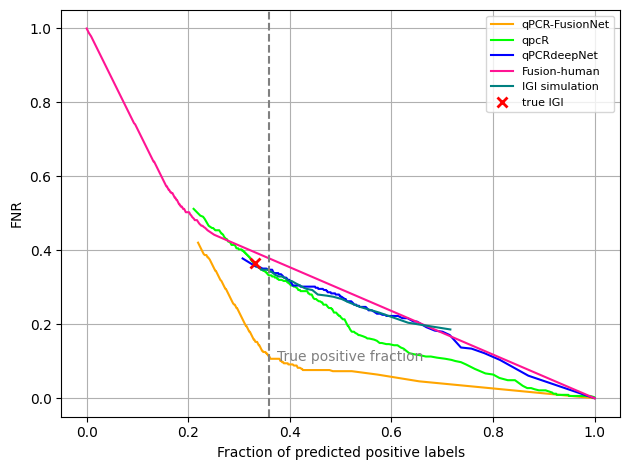

In [132]:

# plt.plot(retest_final_thres_df.pos_pred, 
#          retest_final_thres_df.fnr, 
#          '.', **{'mfc': 'none', 'mec':'blue','mew':0.5}, label='IGI simulation')

# plt.plot(retest_igi_pos_frac, retest_igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

# plt.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fnr, color='green', label='Model')
# plt.plot(qpcr_model_retest_dict_df.pos_frac, qpcr_model_retest_dict_df.fnr, color='orange', label='qpcR')


plt.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fnr, color=color_map.get('fusion'), label='qPCR-FusionNet')

plt.plot(qpcr_model_retest_dict_df.pos_frac, qpcr_model_retest_dict_df.fnr, color=color_map.get('qpcr'), label='qpcR')

plt.plot(deepnet_model_retest_dict_df.pos_frac, deepnet_model_retest_dict_df.fnr, color=color_map.get('deepnet'), label='qPCRdeepNet')

plt.plot(humanbased_model_retest_dict_df.pos_frac, humanbased_model_retest_dict_df.fnr, color=color_map.get('humanbased'), label='Fusion-human')

plt.plot(retest_final_thres_df.pos_pred, 
         retest_final_thres_df.fnr, color=color_map.get('igi'), label='IGI simulation')
plt.plot(retest_igi_pos_frac, retest_igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')


plt.axvline(true_retest_pos_frac, linestyle='--', color='gray')
plt.text(x=true_retest_pos_frac + 0.015, y = 0.1, s='True positive fraction', c='grey')
# plt.xlim(0., 0.6)
# plt.ylim(0.05, 1.)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
plt.tight_layout()
# plt.title('FNR of different methods when varying thresholds on Retest set')
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/fnr_igi_retest.png')

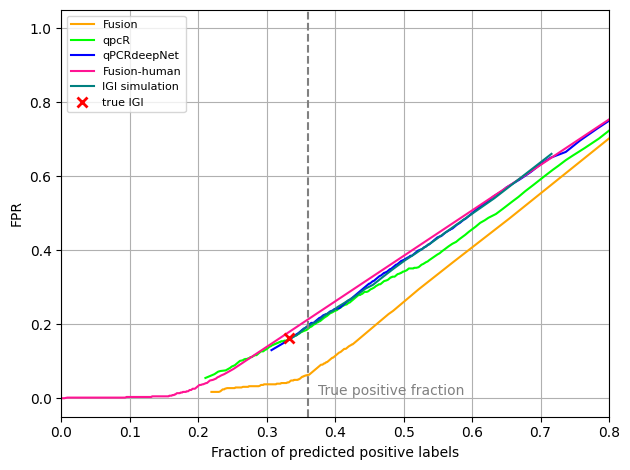

In [134]:


plt.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fpr, color=color_map.get('fusion'), label='Fusion')

plt.plot(qpcr_model_retest_dict_df.pos_frac, qpcr_model_retest_dict_df.fpr, color=color_map.get('qpcr'), label='qpcR')

plt.plot(deepnet_model_retest_dict_df.pos_frac, deepnet_model_retest_dict_df.fpr, color=color_map.get('deepnet'), label='qPCRdeepNet')

plt.plot(humanbased_model_retest_dict_df.pos_frac, humanbased_model_retest_dict_df.fpr, color=color_map.get('humanbased'), label='Fusion-human')

plt.plot(retest_final_thres_df.pos_pred, 
         retest_final_thres_df.fpr, color=color_map.get('igi'), label='IGI simulation')
plt.plot(retest_igi_pos_frac, retest_igi_fpr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')


plt.axvline(true_retest_pos_frac, linestyle='--', color='gray')
plt.text(x=true_retest_pos_frac + 0.015, y = 0.01, s='True positive fraction', c='grey')
plt.xlim(0., 0.8)
# plt.ylim(0,0.6)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FPR')
plt.legend(loc='upper left',fontsize=8)
plt.grid()
plt.tight_layout()
# plt.title('FPR of different methods when varying thresholds on Retest')
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/fpr_igi_retest.png')

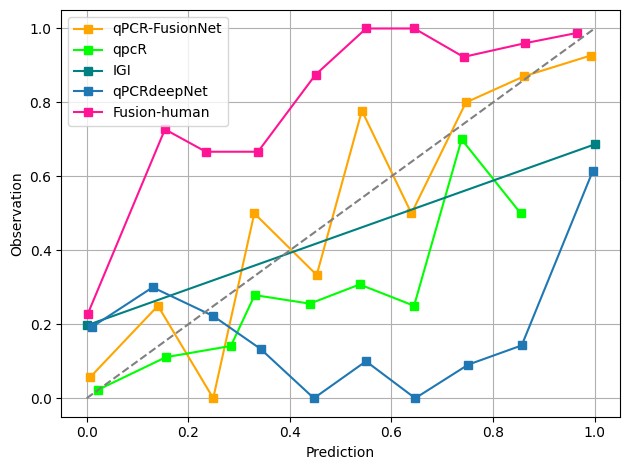

In [131]:

prob_true, prob_pred = calibration_curve(retest_pred.groundtruth_label, retest_pred.outputs, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('fusion'), label='qPCR-FusionNet')

prob_true, prob_pred = calibration_curve(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('qpcr'), label='qpcR')

prob_true, prob_pred = calibration_curve(retest_pred.groundtruth_label, retest_pred.encoded_igi_call, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('igi'), label='IGI')

prob_true, prob_pred = calibration_curve(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('qpcrdeepnet'), label='qPCRdeepNet')

prob_true, prob_pred = calibration_curve(humanbased_retest.groundtruth_label, humanbased_retest.outputs, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', linestyle='-', color=color_map.get('humanbased'), label='Fusion-human')

plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.grid()
plt.xlabel('Prediction')
plt.ylabel('Observation')
plt.legend()
plt.tight_layout()
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/calibration_retest.png')

In [151]:
retest_final_thres_df.to_csv('/media/ssd1/huong/PCR-huong/data/paper_plots/paper_plots_retest_final_thres_df.csv', index=False)